In [1]:
# ============================================================
# 셀 1 - 라이브러리 임포트 및 경로/디바이스 설정
# 학습에 필요한 모든 라이브러리를 불러오고,
# 데이터/모델 저장 경로와 GPU 사용 여부를 설정합니다.
# ============================================================

import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTModel
from PIL import Image
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\user\Desktop\deepfake-detector")
FRAME_DIR = BASE_DIR / "data" / "real_frames"
MODEL_DIR = BASE_DIR / "models" / "occ"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"프레임 경로: {FRAME_DIR}")

Device: cuda
프레임 경로: C:\Users\user\Desktop\deepfake-detector\data\real_frames


In [2]:
# ============================================================
# 셀 2 - 데이터 로드 및 train/val 분할
# 추출된 real 프레임 전체를 불러와서
# 90% train / 10% val로 나눕니다.
# OCC 방식이므로 real 데이터만 사용합니다.
# ============================================================

from sklearn.model_selection import train_test_split

all_frames = (
    list((FRAME_DIR / "documentary").glob("*.jpg")) +
    list((FRAME_DIR / "vlog").glob("*.jpg"))
)

print(f"전체 프레임: {len(all_frames)}장")

train_frames, val_frames = train_test_split(
    all_frames, test_size=0.1, random_state=42
)

print(f"train: {len(train_frames)}장")
print(f"val:   {len(val_frames)}장")

전체 프레임: 86067장
train: 77460장
val:   8607장


In [3]:
# ============================================================
# 셀 3 - Dataset 및 DataLoader 정의
# 프레임 경로 리스트를 받아 이미지를 로드하고
# ViT 입력 규격(224×224, 정규화)에 맞게 전처리합니다.
# num_workers=0: Windows 환경에서 멀티프로세싱 오류 방지
# ============================================================

class RealFrameDataset(Dataset):
    def __init__(self, frame_paths, transform=None):
        self.frame_paths = frame_paths
        self.transform = transform

    def __len__(self):
        return len(self.frame_paths)

    def __getitem__(self, idx):
        img = Image.open(self.frame_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = RealFrameDataset(train_frames, transform=transform)
val_dataset   = RealFrameDataset(val_frames,   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

print(f"train 배치 수: {len(train_loader)}")
print(f"val 배치 수:   {len(val_loader)}")

train 배치 수: 2421
val 배치 수:   269


In [4]:
# ============================================================
# 셀 4 - ViT AutoEncoder 모델 정의
# [Encoder] 사전학습된 ViT-Base로 이미지를 196개 패치 임베딩으로 변환
# [Decoder] 각 패치 임베딩을 원본 픽셀값으로 복원
# 학습 목표: real 이미지를 잘 복원하도록 학습
# 추론 시: reconstruction error가 낮으면 real, 높으면 fake로 판별
# ============================================================

class ViTAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: ViT-Base (ImageNet-21k 사전학습)
        # 이미지를 16×16 패치 196개로 나눠 각각 768차원 임베딩으로 변환
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.encoder_dim = 768

        # Decoder: 패치 임베딩 → 원본 픽셀 복원
        # 768 → 512 → 768 (16×16×3 픽셀값)
        self.decoder = nn.Sequential(
            nn.Linear(self.encoder_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 768),  # 16×16×3 = 768
            nn.Tanh()             # 출력 범위 -1~1 (Normalize 범위와 일치)
        )

    def forward(self, x):
        # x: (B, 3, 224, 224)

        # ViT 인코딩: CLS 토큰 제외, 패치 토큰만 사용
        outputs = self.vit(pixel_values=x)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :]  # (B, 196, 768)

        # 디코딩: 각 패치 임베딩 → 픽셀값 복원
        reconstructed_patches = self.decoder(patch_embeddings)  # (B, 196, 768)

        # 패치 → 이미지 재조합 (14×14 패치 그리드, 각 패치 16×16)
        B = x.shape[0]
        patches = reconstructed_patches.view(B, 14, 14, 16, 16, 3)
        patches = patches.permute(0, 5, 1, 3, 2, 4)  # (B, 3, 14, 16, 14, 16)
        image = patches.contiguous().view(B, 3, 224, 224)

        return image

model = ViTAutoEncoder().to(DEVICE)
print("모델 구성 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

모델 구성 완료
파라미터 수: 87,176,960


In [5]:
# ============================================================
# 셀 5 - 학습 및 검증 함수 정의
# train_epoch: 한 에폭 학습 (역전파 포함)
# val_epoch:   한 에폭 검증 (역전파 없음, 손실만 측정)
# 손실함수: MSELoss (입력 이미지와 복원 이미지의 픽셀 차이)
# ============================================================

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch_idx, imgs in enumerate(loader):
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()

        reconstructed = model(imgs)
        loss = criterion(reconstructed, imgs)  # 복원 오차 계산

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  배치 [{batch_idx+1}/{len(loader)}] loss: {loss.item():.4f}")

    return total_loss / len(loader)


def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for imgs in loader:
            imgs = imgs.to(DEVICE)
            reconstructed = model(imgs)
            loss = criterion(reconstructed, imgs)
            total_loss += loss.item()

    return total_loss / len(loader)

In [6]:
# ============================================================
# 셀 6 - 체크포인트 저장/로드 함수 정의
# 매 에폭마다 checkpoint.pth에 현재 상태를 저장합니다.
# val_loss가 개선될 때만 best_model.pth를 별도 저장합니다.
# 학습 중단 후 재시작 시 checkpoint.pth에서 이어받습니다.
# ============================================================

CHECKPOINT_PATH = MODEL_DIR / "checkpoint.pth"
BEST_MODEL_PATH = MODEL_DIR / "best_model.pth"
HISTORY_PATH    = MODEL_DIR / "history.json"

def save_checkpoint(model, optimizer, epoch, best_val_loss, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
    }, CHECKPOINT_PATH)
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f)

def load_checkpoint(model, optimizer):
    if not CHECKPOINT_PATH.exists():
        print("체크포인트 없음 — 처음부터 학습 시작")
        return 0, float("inf"), {"train_loss": [], "val_loss": []}
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    history = json.load(open(HISTORY_PATH)) if HISTORY_PATH.exists() else {"train_loss": [], "val_loss": []}
    print(f"체크포인트 로드: epoch {ckpt['epoch']} | best_val_loss: {ckpt['best_val_loss']:.4f}")
    return ckpt["epoch"], ckpt["best_val_loss"], history

In [7]:
# ============================================================
# 셀 7 - 학습 실행
# 총 30 에폭 학습, 중단 후 재시작 시 자동으로 이어받습니다.
# optimizer: AdamW (lr=1e-4)
# 매 에폭 후 체크포인트 저장, val_loss 개선 시 best_model 저장
# 5 에폭마다 중간 체크포인트를 별도 파일로 저장합니다.
# 학습 시작/종료 시간 및 총 소요 시간을 출력합니다.
# ============================================================

EPOCHS = 30
LR     = 1e-4
SAVE_INTERVAL = 5  # 몇 에폭마다 중간 저장할지

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

start_epoch, best_val_loss, history = load_checkpoint(model, optimizer)

start_time = datetime.now()
print(f"학습 시작 (epoch {start_epoch+1} ~ {EPOCHS})")
print(f"Device: {DEVICE}")
print(f"시작 시간: {start_time.strftime('%Y-%m-%d %H:%M:%S')}\n")

for epoch in range(start_epoch, EPOCHS):
    epoch_start = datetime.now()

    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_loss   = val_epoch(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    elapsed = (datetime.now() - epoch_start).seconds
    print(f"\nEpoch [{epoch+1}/{EPOCHS}] | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | {elapsed}초")

    # best model 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✓ best model 저장 (val_loss: {best_val_loss:.4f})")

    # 매 에폭 체크포인트 저장 (이어받기용)
    save_checkpoint(model, optimizer, epoch + 1, best_val_loss, history)

    # 5 에폭마다 중간 스냅샷 별도 저장
    if (epoch + 1) % SAVE_INTERVAL == 0:
        snapshot_path = MODEL_DIR / f"snapshot_epoch{epoch+1:02d}.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
        }, snapshot_path)
        print(f"  ✓ 중간 스냅샷 저장: snapshot_epoch{epoch+1:02d}.pth")
        print(f"  현재까지 학습 요약:")
        print(f"    - 완료 에폭: {epoch+1}/{EPOCHS}")
        print(f"    - 현재 val_loss: {val_loss:.4f}")
        print(f"    - 최저 val_loss: {best_val_loss:.4f}")
        print(f"    - 저장된 스냅샷: {[f'snapshot_epoch{e:02d}.pth' for e in range(SAVE_INTERVAL, epoch+2, SAVE_INTERVAL)]}")
        print("-" * 50)

end_time = datetime.now()
elapsed_total = end_time - start_time
hours, remainder = divmod(elapsed_total.seconds, 3600)
minutes, seconds = divmod(remainder, 60)

print("\n학습 완료!")
print(f"시작 시간: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"종료 시간: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"총 소요 시간: {hours}시간 {minutes}분 {seconds}초")
print(f"최종 best val_loss: {best_val_loss:.4f}")
print(f"모델 저장 경로: {MODEL_DIR}")

체크포인트 로드: epoch 23 | best_val_loss: 0.0006
학습 시작 (epoch 24 ~ 30)
Device: cuda
시작 시간: 2026-04-19 05:16:45

  배치 [50/2421] loss: 0.0007
  배치 [100/2421] loss: 0.0005
  배치 [150/2421] loss: 0.0005
  배치 [200/2421] loss: 0.0005
  배치 [250/2421] loss: 0.0007
  배치 [300/2421] loss: 0.0008
  배치 [350/2421] loss: 0.0005
  배치 [400/2421] loss: 0.0005
  배치 [450/2421] loss: 0.0005
  배치 [500/2421] loss: 0.0004
  배치 [550/2421] loss: 0.0006
  배치 [600/2421] loss: 0.0007
  배치 [650/2421] loss: 0.0006
  배치 [700/2421] loss: 0.0004
  배치 [750/2421] loss: 0.0007
  배치 [800/2421] loss: 0.0007
  배치 [850/2421] loss: 0.0005
  배치 [900/2421] loss: 0.0006
  배치 [950/2421] loss: 0.0005
  배치 [1000/2421] loss: 0.0005
  배치 [1050/2421] loss: 0.0007
  배치 [1100/2421] loss: 0.0006
  배치 [1150/2421] loss: 0.0006
  배치 [1200/2421] loss: 0.0005
  배치 [1250/2421] loss: 0.0005
  배치 [1300/2421] loss: 0.0005
  배치 [1350/2421] loss: 0.0005
  배치 [1400/2421] loss: 0.0007
  배치 [1450/2421] loss: 0.0007
  배치 [1500/2421] loss: 0.0005
  배치 [1550/242

C:\Users\user\AppData\Local\Temp\ipykernel_1232\2270372689.py:17: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1232\2270372689.py:17: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1232\2270372689.py:17: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1232\2270372689.py:17: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_1232\2270372689.py:18: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig(str(MODEL_DIR / "loss_curve.png"))
C:\Users\user\AppData\Local\Temp\ipykernel_1232\2270372689.py:18: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE

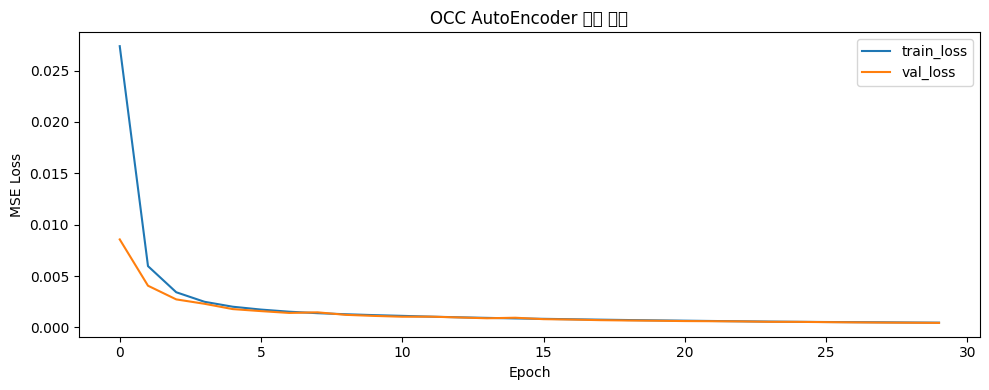

In [8]:
# ============================================================
# 셀 8 - 학습 곡선 시각화
# train/val loss 변화를 그래프로 확인합니다.
# loss가 수렴하지 않거나 val_loss가 튀면 학습률 조정이 필요합니다.
# 그래프는 models/occ/loss_curve.png 에도 저장됩니다.
# ============================================================

history = json.load(open(HISTORY_PATH))

plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"],   label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("OCC AutoEncoder 학습 곡선")
plt.legend()
plt.tight_layout()
plt.savefig(str(MODEL_DIR / "loss_curve.png"))
plt.show()